# Import av bibliotek och inläsning av data 

Här läses datasetet in från CSV-filen och konverteras till ett NumPy-array. Tomma rader tas bort för att säkerställa att regressionsmodellen får ett komplett och korrekt dataset. Här kontrolleras även datasetets dimensioner för att verifiera att inläsningen lyckats.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from linear_regression_ny import LinearRegression

data = np.genfromtxt("C:/Users/samue/Documents/code/Statistiska-metoder-Samuel-Airisniemi/Labb_ny/housing.csv", delimiter = ",", dtype = str, skip_header = 1)
data = np.char.strip(data)
data = data[~np.any(data == "", axis = 1)]
print("Dataset shape:", data.shape)
print("First row:", data[0])

Dataset shape: (20433, 10)
First row: ['-122.23' '37.88' '41.0' '880.0' '129.0' '322.0' '126.0' '8.3252'
 '452600.0' 'NEAR BAY']


# Översikt av datasetets struktur

Här undersöks hur många kolumner datasetet innehåller. Detta är viktigt för att säkerställa att variablerna separerats korrekt i senare steg, särskilt när jag skiljer på features och målvariabler.

In [2]:
num_cols = data.shape[1]
print("Number of columns:", num_cols)

Number of columns: 10


# Model 1: Linjär regression med enbart numeriska variabler

I denna modell används endast de numeriska variablerna i datasetet. Modellen tränas med Ordinary Least Squares (OLS) och resultatet sammanfattas med koefficienter, standardfel, t-värden, p-värden, R^2, RMSE, och F-test. Denna modell fungerar som en baseline för att senare kunna jämföra effekten av att inkludera kategoriska variabler.

In [3]:
X1 = data[:, 0:8].astype(float)
y1 = data[:, 8].astype(float)

feature_names_1 = ["Longitude", "Latitude", "HouseAge", "TotalRooms", "TotalBedrooms", "Population", "Households", "MedInc"]

model1 = LinearRegression(confidence_level = 0.95)
model1.fit(X1, y1, feature_names=feature_names_1)

print("MODEL 1 (Numeric only):")
model1.summary()

MODEL 1 (Numeric only):

Linear Regression Summary
n (samples): 20433
d (features): 8
Coefficients:
Intercept                 -3585395.747900
Longitude                 -42730.120454
Latitude                  -42509.736942
HouseAge                   1157.900307
TotalRooms                   -8.249725
TotalBedrooms               113.820707
Population                  -38.385578
Households                   47.701351
MedInc                    40297.521715
SSE: 98856034611384.437500
Sample variance (sigma^2): 4840189708.743853
Standard deviation: 69571.471946
RMSE: 69556.148396
R^2: 0.636912
t-test results (individual significance):
Feature                           beta      std_err            t      p-value
Intercept                 -3585395.747900 62900.542833   -57.001030     0.000000
Longitude                 -42730.120454   717.086965   -59.588477     0.000000
Latitude                  -42509.736942   676.951557   -62.795833     0.000000
HouseAge                   1157.900307    43.38

# Pearson-korrelation mellan numeriska features

Här beräknas Pearson-korrelationsmatrisen för de numeriska variablerna. Detta används för att identifiera linjära samband och potentiell multikollinearitet mellan features. Vilket är viktigt för att bedöma modellens stabilitet och tolkbarhet.

In [4]:
np.set_printoptions(precision = 3, suppress = True)
pearson = model1.pearson_matrix(X1)

print("Pearson correlation matrix:")
print(pearson)

Pearson correlation matrix:
[[ 1.    -0.925 -0.109  0.045  0.07   0.1    0.057 -0.016]
 [-0.925  1.     0.012 -0.037 -0.067 -0.109 -0.072 -0.08 ]
 [-0.109  0.012  1.    -0.361 -0.32  -0.296 -0.303 -0.118]
 [ 0.045 -0.037 -0.361  1.     0.93   0.857  0.919  0.198]
 [ 0.07  -0.067 -0.32   0.93   1.     0.878  0.98  -0.008]
 [ 0.1   -0.109 -0.296  0.857  0.878  1.     0.907  0.005]
 [ 0.057 -0.072 -0.303  0.919  0.98   0.907  1.     0.013]
 [-0.016 -0.08  -0.118  0.198 -0.008  0.005  0.013  1.   ]]


# Visualisering av korrelationsmatrisen

Korrelationsmatrisen visualiseras som en heatmap för att ge en tydlig grafisk översikt över sambanden mellan variablerna. Detta underlättar tolkningen av vilka features som är starkt korrelerade.

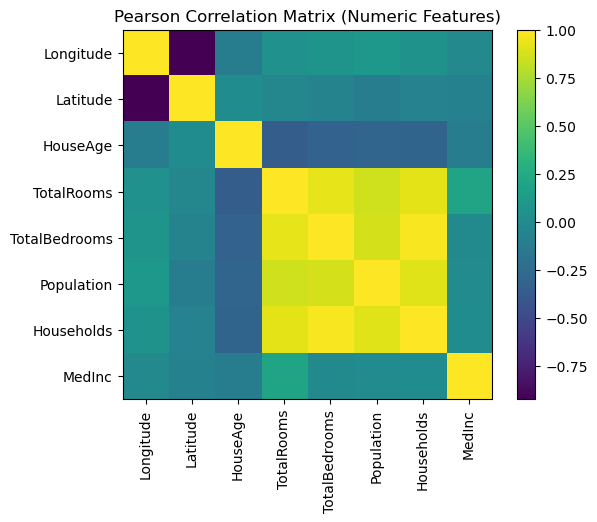

In [5]:
plt.imshow(pearson)
plt.colorbar()
plt.title("Pearson Correlation Matrix (Numeric Features)")
plt.xticks(range(len(feature_names_1)), feature_names_1, rotation = 90)
plt.yticks(range(len(feature_names_1)), feature_names_1)
plt.show()

# Modell 2: Linjär regression med kategorisk variabel (One-hot encoding)

I denna modell inkluderas även den kategoriska variabeln "OceanProximity" som först omvandlas till dummy-variabler via One-hot encoding. Detta gör det möjligt att analysera hur olika goegrafiska kategorier påverkar huspriserna. Modellen tränas och sammanfattas på samma sätt som Modell 1. Vilket möjliggör en direkt jämförelse mellan modellerna.

In [6]:
feature_names_2 = feature_names_1 + ["OceanProximity"]

X_raw = np.column_stack((data[:, :8], data[:, 9]))
categorical_cols = [8]

model2 = LinearRegression()
X_encoded, new_names = model2.one_hot_encode(
    X_raw,
    categorical_cols=categorical_cols,
    feature_names=feature_names_2,
    drop_first=True
)

model2.fit(X_encoded, y1, feature_names=new_names)
print("MODEL 2 (Numeric + One-Hot Encoded Categorical):")
model2.summary()

MODEL 2 (Numeric + One-Hot Encoded Categorical):

Linear Regression Summary
n (samples): 20433
d (features): 12
Coefficients:
Intercept                 -2269954.116141
Longitude                 -26812.989282
Latitude                  -25482.184831
HouseAge                   1072.520042
TotalRooms                   -6.193264
TotalBedrooms               100.556290
Population                  -37.969083
Households                   49.617326
MedInc                    39259.572876
OceanProximity_INLAND     -39284.300195
OceanProximity_ISLAND     152901.941119
OceanProximity_NEAR BAY   -3954.051625
OceanProximity_NEAR OCEAN  4278.134324
SSE: 96255324900327.500000
Sample variance (sigma^2): 4713776929.496940
Standard deviation: 68656.951065
RMSE: 68635.106931
R^2: 0.646464
t-test results (individual significance):
Feature                           beta      std_err            t      p-value
Intercept                 -2269954.116141 88013.881732   -25.790865     0.000000
Longitude            

# Jämförelse mellan Modell 1 och Modell 2

Här jämförs de två modellerna med avseende på R^2 ocg RMSE. Syftet är att utvärdera om inkluderingen av den kategoriska variabeln förbättrar modellens förklarningsgrad och prediktionsförmåga. Detta steg visar tydligt värdet av att hantera kategoriska variabler korrekt i regressionsanalys.

In [7]:
print(f"Model 1 R^2:  {model1.r2():.6f}")
print(f"Model 2 R^2:  {model2.r2():.6f}")

print(f"Model 1 RMSE: {model1.rmse():.6f}")
print(f"Model 2 RMSE: {model2.rmse():.6f}")

Model 1 R^2:  0.636912
Model 2 R^2:  0.646464
Model 1 RMSE: 69556.148396
Model 2 RMSE: 68635.106931
